# Gaia downloads: single and batch

Download one calibrated SED, then a small catalogue with raw XP/RVS/epoch products.
Run top to bottom with an internet connection.

From the sedkit checkout, install once: `pip install -e ".[download,notebook]"`.

In [1]:
%matplotlib inline
from sedkit import download, plot, query_gaia, download_gaia
from astropy.table import Table

## 1. Single star → SED

`download` combines calibrated Gaia XP with Gaia-linked 2MASS/AllWISE photometry.
It returns an `SED` and saves the measurements locally.

Gaia DR3 1521154374020165376: 66 valid channels


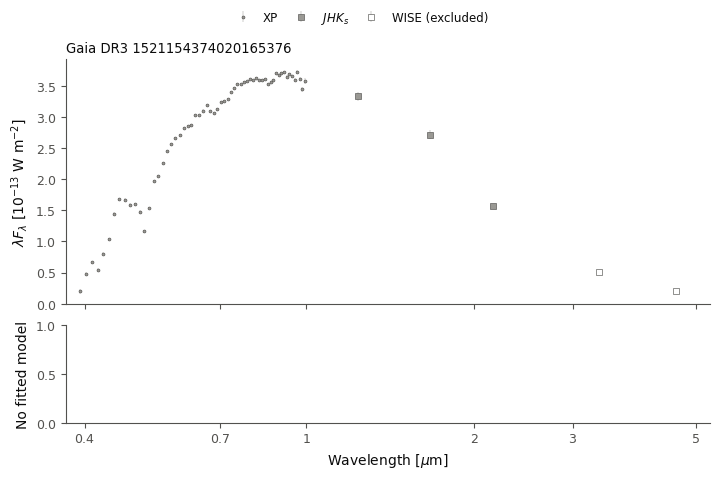

In [2]:
sed = download("1521154374020165376", cache_dir="data/gaia_tutorial/single")
print(f"Gaia DR3 {sed.source_id}: {sed.mask.sum()} valid channels")
fig = plot(sed)

## 2. Batch → catalogue + raw files

Start with three stars with XP spectra selected by observed parallax (approximately within 300 pc).
This is a download example, not a complete FGKM sample.

In [3]:
catalogue = query_gaia("""
    SELECT TOP 3 source_id, parallax, phot_g_mean_mag, bp_rp
    FROM gaiadr3.gaia_source
    WHERE parallax >= 3.3333333333333335
      AND phot_g_mean_mag BETWEEN 8 AND 10 AND bp_rp BETWEEN 0.35 AND 4.5
      AND has_xp_continuous = 'true'
""", tap="ari", cache_dir="data/gaia_tutorial/catalogue_xp")
catalogue

source_id,parallax,phot_g_mean_mag,bp_rp
,mas,mag,mag
int64,float64,float32,float32
4705158701656527360,8.944345193580602,8.000006,0.61865664
5913984428312720896,3.5104602320160128,8.000151,1.2423854
6373877019413222784,9.431045542486352,8.000326,0.9864702


In [4]:
batches = download_gaia(
    catalogue["source_id"],
    products=["XP_CONTINUOUS", "RVS", "EPOCH_PHOTOMETRY"],
    cache_dir="data/gaia_tutorial/products_xp",
    batch_size=2, workers=2,
)
Table(rows=[(b["product"], len(b["source_ids"]),
             len(b["unavailable_source_ids"]), b["cached"])
            for b in batches],
      names=["product", "downloaded", "unavailable", "cached"])

product,downloaded,unavailable,cached
str16,int64,int64,bool
XP_CONTINUOUS,2,0,False
RVS,0,2,False
EPOCH_PHOTOMETRY,0,2,False
XP_CONTINUOUS,1,0,False
RVS,0,1,False
EPOCH_PHOTOMETRY,0,1,False


Each record contains `path` (a FITS ZIP), delivered `source_ids`, and
`unavailable_source_ids`. These are native archive products; XP is not calibrated
into an `SED` by this batch call. Inspect the first available file:

In [5]:
from io import BytesIO
from zipfile import ZipFile

path = next(b["path"] for b in batches if b["path"] is not None)
with ZipFile(path) as archive:
    name = next(n for n in archive.namelist() if n.lower().endswith(".fits"))
    raw = Table.read(BytesIO(archive.read(name)), format="fits")
print(path)
print(f"{len(raw)} rows; columns: {', '.join(raw.colnames)}")

data/gaia_tutorial/products_xp/000000-XP_CONTINUOUS.zip
2 rows; columns: source_id, solution_id, bp_basis_function_id, bp_degrees_of_freedom, bp_n_parameters, bp_n_measurements, bp_n_rejected_measurements, bp_standard_deviation, bp_chi_squared, bp_coefficients, bp_coefficient_errors, bp_coefficient_correlations, bp_n_relevant_bases, bp_relative_shrinking, rp_basis_function_id, rp_degrees_of_freedom, rp_n_parameters, rp_n_measurements, rp_n_rejected_measurements, rp_standard_deviation, rp_chi_squared, rp_coefficients, rp_coefficient_errors, rp_coefficient_correlations, rp_n_relevant_bases, rp_relative_shrinking


Rerun the download cells to reuse completed files or resume after interruption.
When changing the batch query or requested IDs/products, use new cache directories.
Keep Gaia IDs as integers or strings. These examples use DR3; DR4 remains unvalidated.

For more sources, increase `TOP 3` and use e.g. `batch_size=100`.
See [API options](../docs/gaia.md).